In [193]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import trange

In [198]:
# An helper method for generating integers in a given range (for connection weights)
def random_int_gen(low=-2, high=5, size=None):
    return np.random.randint(low, high, size=size)

# A class for connected neural clusters
class NeuralCluster():
    def __init__(self, N:int, density):
        # Size of the network
        self.N = N
        # Weights of the connection : sparse matrix of density d
        w_base = 10* np.diag(random_int_gen(size=N-1),k=1)
        w_base[-1,0] = 10* random_int_gen()
        self.w = w_base + sp.sparse.random_array((N,N), density = density, data_sampler=random_int_gen)
        # initialize the array that will hold the firing rates (size 1xN)
        self.x = np.empty((1,N))
        # sigmoid activation function (uniform for all neurons in the cluster)
        self.fct = lambda y:1/(1+np.exp(-y))
        # External input is set to zero
        self.I = 0

    # Set the external input. Positive values = excitation
    def set_input(self, I):
        self.I = I

    # Initialize the cluster at x0 (size N), for n_steps time steps of dt s (total duration: n_steps*dt)
    def init_dynamics(self, x0, n_steps:int, dt):
        self.n_steps = n_steps
        self.dt = dt
        self.T = dt * n_steps
        self.x = np.empty((n_steps, self.N))
        # This will hold the flow at time t
        self.flow = np.zeros((n_steps, self.N))
        self.x[0] = x0
        # Time scale
        self.t = dt * np.arange(n_steps)
        self.spike_trains = np.array([])
        self.spike_count = np.array([])

    # At a given time step, compute the flow of the cluster F(x) = -x + f(wx+I)
    def compute_flow(self, idx:int, I=0):
        self.flow[idx] = - self.x[idx] + self.fct(self.w @ self.x[idx] + self.I + I)

    #At a given time step, compute the dynamics using Euler's method: x(t+dt) = x(t) + dt * F(x(t))
    def compute_dynamics_step(self, idx:int):
        self.compute_flow(idx)
        self.x[idx+1] = self.x[idx] + self.dt * self.flow[idx]
        self.x[idx+1] = np.where(self.x[idx+1] < 0, 0, self.x[idx+1])

    # Compute the full dynamics from initial condition x0 (size N), total duration T, time step dt
    def compute_dynamics(self, x0, T, dt):
        n_steps = int(T/dt)
        self.init_dynamics(x0, n_steps, dt)
        for idx in trange(n_steps - 1, desc="Computing dynamics steps"):
            self.compute_dynamics_step(idx)
        self.compute_poisson_spikes()
        self.compute_spike_count()

    def compute_poisson_spikes(self):
        self.spike_trains = np.empty((self.n_steps, self.N))
        for t in trange(self.n_steps, desc="Computing Poisson spiking"):
            for i in range(self.N):
                p = self.dt * self.x[t, i]
                self.spike_trains[t, i] = np.random.choice([0, 1], p=[1-p, p]) 

    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spike_trains[:,i]
            event.append(np.nonzero(st)[0])
        plt.eventplot(event, colors='k', zorder = 0)
    
    # TO BE CORRECTED: From the instantaneous firing rate, compute Poisson spiking.
    def compute_spike_count(self):
        self.spike_count = np.sum(self.spike_trains, axis=0)

# Helper method to plot the dynamics (one color for the whole cluster)
def plot_dynamics(cluster, color):
    t = cluster.t
    x = cluster.x
    for i in range(cluster.N):
        plt.plot(t, x[:, i], c=color)

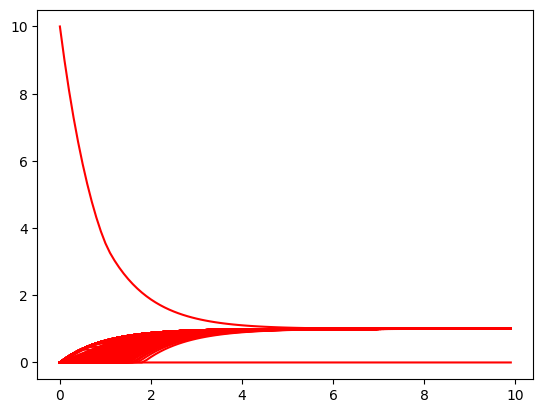

In [152]:
cluster1 = NeuralCluster(1000, 0.1)
cluster1.set_input(-10)
#x0 = np.random.rand(cluster1.N)
x0 = np.zeros(cluster1.N)
x0[0]=10
cluster1.compute_dynamics(x0, 10, 0.1)
plot_dynamics(cluster1, color='r')

cluster2 = NeuralCluster(1000, 0.1)

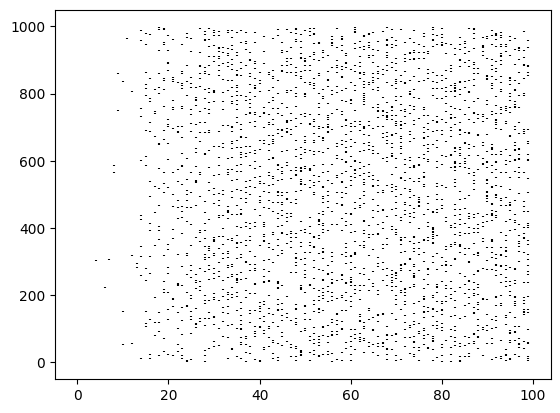

In [138]:
cluster1.plot_raster()

In [199]:
# A class to implement the whole network : two conencted cluseters, linked by inhibitory basket cells. 
# TO BE WRITTEN
class ConnectedClusters(NeuralCluster):
    def __init__(self, N1, N2, n_baskets):
        self.N1 = N1
        self.N2 = N2
        self.n_baskets = n_baskets
        # Cluster 1
        self.cluster1 = NeuralCluster(N1, 0.1)
        # Cluster 2
        self.cluster2 = NeuralCluster(N2, 0.1)
        # Basket cell affectation array: to each neuron in cluster1/2 correspond one basket cell. Size 2xN.
        self.basket_affectation = np.concatenate([np.random.randint(0, n_baskets, size=N1),
                                                  np.random.randint(0, n_baskets, size=N2)])
        
        super().__init__(N1 + N2 + n_baskets, 0)
        self.w = np.empty((N1 + N2 + n_baskets, N1 + N2 + n_baskets))
        for i in range(N1):
            b = np.zeros(n_baskets)
            b[self.basket_affectation[i]] = -50
            self.w[i] = np.concatenate([self.cluster1.w[i], np.zeros(N2), b])
        for i in range(N2):
            b = np.zeros(n_baskets)
            b[self.basket_affectation[i]] = -50
            self.w[N1+i] = np.concatenate([np.zeros(N1), self.cluster2.w[i], b])
        for i in range(n_baskets):
            self.w[N1+N2+i] = np.concatenate([np.where(self.basket_affectation==i, 1, 0),
                                            np.zeros(n_baskets)])

    def compute_dynamics(self, x0, T, dt):
        super().compute_dynamics(x0, T, dt)
        self.cluster1.x = self.x[:, :self.N1]
        self.cluster2.x = self.x[:, self.N1:self.N1+self.N2]
        self.cluster1.t = self.t
        self.cluster2.t = self.t
        self.cluster1.spike_trains = self.spike_trains[:, :self.N1]
        self.cluster2.spike_trains = self.spike_trains[:, self.N1:self.N1+self.N2]
        self.cluster1.compute_spike_count()
        self.cluster2.compute_spike_count()
    
    def plot_raster(self):
        event = []
        for i in range(self.N):
            st = self.spike_trains[:,i]
            event.append(np.nonzero(st)[0])
        colors=np.concatenate([np.full(self.N1, 'k'), np.full(self.N2, 'b'), np.full(self.n_baskets, 'r')])
        plt.eventplot(event, colors=colors, zorder = 0)

In [200]:
N1 = 100
N2 = 100
n_baskets = 25

model = ConnectedClusters(N1, N2, n_baskets)
I = 25* np.concatenate([np.ones(N1), np.zeros(N2 + n_baskets)])
model.set_input(I)
x0 = np.concatenate([10*np.random.rand(N1 + N2), np.zeros(n_baskets)])
model.compute_dynamics(x0, 20, 0.001)

Computing Poisson spiking: 100%|████████████████████████████████████████████████| 20000/20000 [00:47<00:00, 422.37it/s]


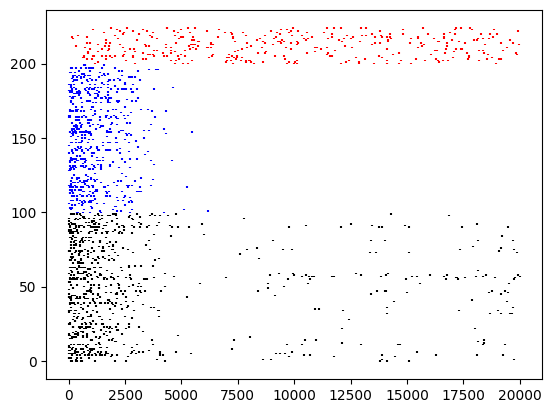

In [201]:
model.plot_raster()

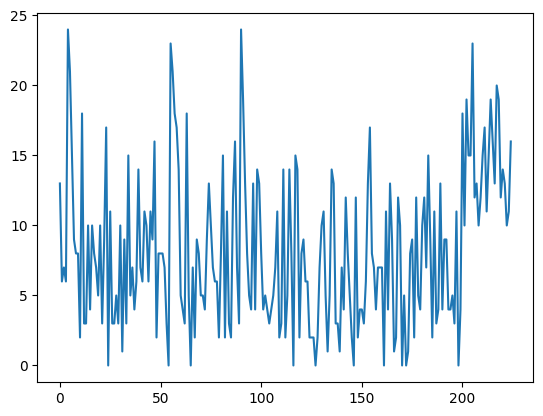

In [207]:
plt.plot(model.spike_count)

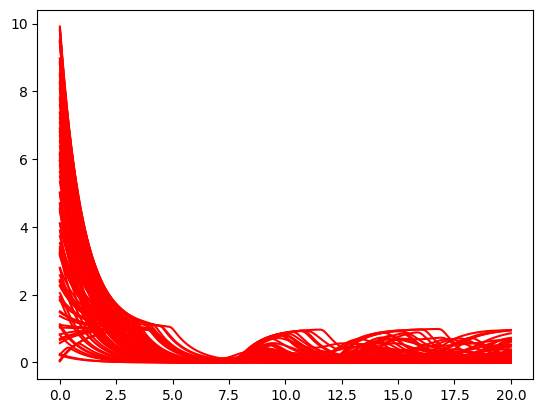

In [205]:
plot_dynamics(model.cluster1, color='r')